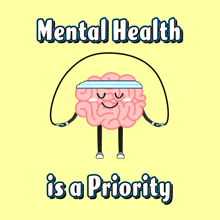

# 🧠 **MindWell - Mental Health Score Predictor**

### **Project Overview**:
This project analyzes the relationship between students' social media usage, lifestyle habits, sleep patterns, study behavior, physical activity, and mental health.

The objective is to build a Machine Learning model that can predict a student's **Mental Health Score** based on relevant behavioral and lifestyle factors.

### **Problem Statement**:

The increasing use of social media has significantly influenced students' daily routines, including their sleep, study habits, physical activity, and overall well-being.

Can a student's social media usage, sleep, study habits, physical activity, and other behavioral characteristics be used to predict their **Mental Health Score**?

To answer this question, we will use **Student Social Media and Mental Health Impact Dataset**.

### **Dataset Information:**
The Student Social Media and Mental Health Impact Dataset is a behavioral analytics dataset containing 5,000 student records designed to explore the relationship between social media usage, lifestyle habits, and mental well-being.

**Features**
- Age – Student age
- Gender – Gender of the student
- Country – Country of residence
- Academic_Level – Educational level of the student
- Most_Used_Platform – Primary social media platform used
- Purpose_Of_Use – Main purpose of social media usage
- Avg_Daily_Usage_Hours – Average hours spent daily on social media
- Daily_Unlocks – Estimated number of device unlocks per day
- Study_Hours – Average study time per day
- Physical_Activity_Hours – Daily physical activity duration
- Sleep_Hours_Per_Night – Average sleep duration per night
- Stress_Level – Self-reported stress category
- Mental_Health_Score – Mental well-being score

## 1. Import Libraries

In [26]:
# Data manipulation and visualization 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')

# Data preprocessing
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Performance metrices  
from sklearn.metrics import (r2_score,
                             mean_absolute_error,
                             root_mean_squared_error)

# Hyperparameter Tuning 
from sklearn.model_selection import RandomizedSearchCV

# Save model 
import joblib 

## 2.  Load the Dataset

In [2]:
# Dataset
df = pd.read_csv('../dataset/Student Social Media And Mental Health Impact.csv')

## 3. Exploratory Data Analysis (EDA)

In [4]:
# Check first five rows of the dataset
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [11]:
# Check shape of the dataset
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 5000
Number of Columns: 13


In [12]:
# Check info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   str    
 2   Country                  5000 non-null   str    
 3   Academic_Level           5000 non-null   str    
 4   Most_Used_Platform       5000 non-null   str    
 5   Purpose_Of_Use           5000 non-null   str    
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   str    
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), str(6)
memory usage: 507.9 KB


In [13]:
# Check statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,20.82180,1.736620,18.0,19.0,21.0,22.0,24.0
Avg_Daily_Usage_Hours,5000.0,5.07846,1.653913,1.0,3.8,5.0,6.3,8.8
Daily_Unlocks,5000.0,171.45260,42.858254,62.0,140.0,171.0,204.0,273.0
Study_Hours,5000.0,3.00842,1.637018,0.3,1.5,2.8,4.2,8.3
Physical_Activity_Hours,5000.0,1.75100,0.668398,-0.4,1.3,1.7,2.2,4.1
Sleep_Hours_Per_Night,5000.0,6.63458,1.221391,3.6,5.6,6.6,7.5,9.9
Mental_Health_Score,5000.0,6.23098,1.278701,3.6,5.1,6.1,7.1,9.4


Notice: We can see here in Physical_Activity_Hours, there is an unrealistic value which is **-0.4** and we have to handle this.

In [14]:
# Check missing values
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [5]:
# Check duplicate values
print(df.duplicated().sum())

2


In [73]:
# Check categorical columns unique items
for col in df.select_dtypes(include=['object', 'string']).columns:
    print(f'{col}\n{df[col].unique()}')
    print('-' * 40, '\n')

Gender
<StringArray>
['Male', 'Female']
Length: 2, dtype: str
---------------------------------------- 

Country
<StringArray>
[      'Other',      'Canada',         'USA',       'India',   'Australia',
          'UK',     'Germany',  'Bangladesh',      'Brazil',       'Japan',
 ...
     'Lebanon',        'Iraq',       'Yemen',       'Syria', 'Afghanistan',
    'Pakistan',       'Nepal',      'Bhutan',   'Sri Lanka',    'Maldives']
Length: 111, dtype: str
---------------------------------------- 

Academic_Level
<StringArray>
['Undergraduate', 'Graduate', 'High School']
Length: 3, dtype: str
---------------------------------------- 

Most_Used_Platform
<StringArray>
[ 'Facebook',  'LinkedIn', 'Instagram',  'Snapchat',   'Twitter',   'YouTube',
    'TikTok',      'LINE', 'KakaoTalk', 'VKontakte',  'WhatsApp',    'WeChat']
Length: 12, dtype: str
---------------------------------------- 

Purpose_Of_Use
<StringArray>
['Networking', 'Education', 'Entertainment', 'News']
Length: 4, dtype: s

In [74]:
# Check total unique country 
len(df['Country'].unique())

111

In [17]:
# Define numerical columns, categorical columns and target column

# Target column
target_column = 'Mental_Health_Score'

# Numerical columns
numerical_columns = [col for col in df.select_dtypes(include='number').columns if col != target_column]

# Categorical columns
categorical_columns = [col for col in df.select_dtypes(include=['object', 'string', 'category']).columns if col != target_column]

print("Target Column:")
print(target_column)

print("\nNumerical Columns:")
print(numerical_columns,"Total:",len(numerical_columns))

print("\nCategorical Columns:")
print(categorical_columns,"Total:",len(categorical_columns))

Target Column:
Mental_Health_Score

Numerical Columns:
['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night'] Total: 6

Categorical Columns:
['Gender', 'Country', 'Academic_Level', 'Most_Used_Platform', 'Purpose_Of_Use', 'Stress_Level'] Total: 6


#### Observations:
- The dataset contains **5,000** rows and **13** columns.

- There are no missing values in the dataset.

- There are **2** duplicate records in the dataset.

- The `Physical_Activity_Hours` column contains an unrealistic value of **-0.4** hours.

- The dataset contains **6** numerical features, **6** categorical features, and **1** target variable (`Mental_Health_Score`).

## Visualization

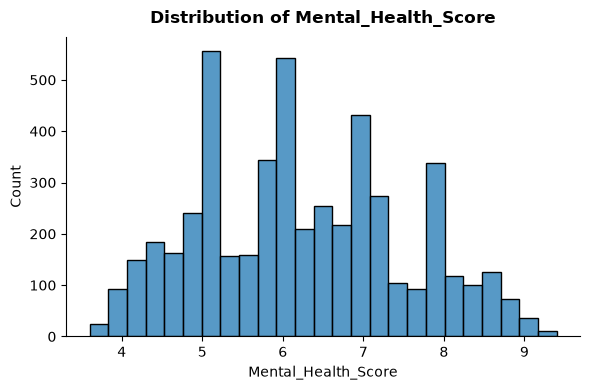

In [58]:
# Check distribution of the target column - Mental_Health_Score
plt.figure(figsize=(6,4))
sns.histplot(data=df, x=target_column)
plt.title('Distribution of Mental_Health_Score',fontweight='bold',pad=10)
sns.despine()
plt.tight_layout()

# Save figure
plt.savefig(
    '../plots/Distribution of Mental_Health_Score.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

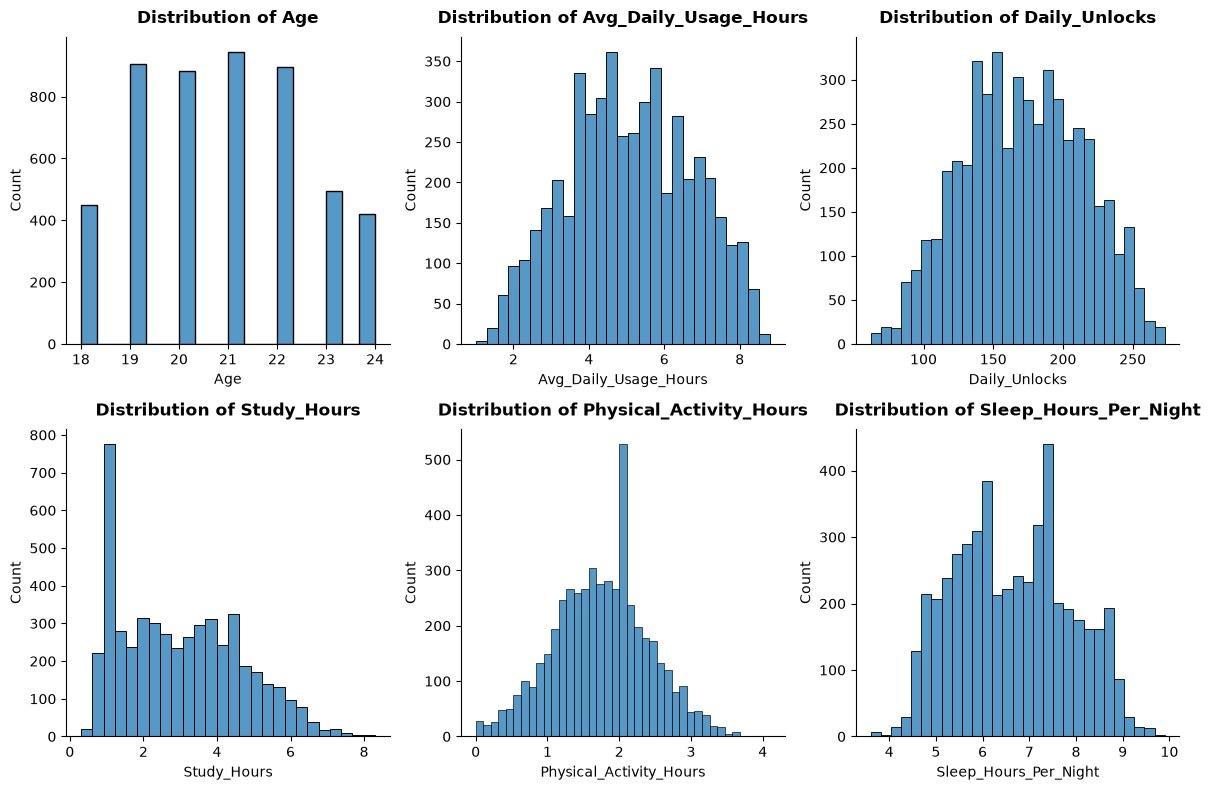

In [66]:
# Check distribution of other numerical columns
plt.figure(figsize=(12, 8))
for i,col in enumerate(numerical_columns, 1):
  plt.subplot(2,3,i)
  sns.histplot(data=df, x=col)
  plt.title(f'Distribution of {col}', fontweight='bold', pad=10)
  plt.xlabel(col)
  sns.despine()
plt.tight_layout()

# Save figure
plt.savefig(
    '../plots/Numerical_Column_Distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [30]:
# Check frequency distribution of all categorical columns
for col in df.select_dtypes(include=['object', 'string']).columns:
    print(f'{df[col].value_counts()}')
    print('-' * 40, '\n')

Gender
Male      2635
Female    2365
Name: count, dtype: int64
---------------------------------------- 

Country
Other         1880
India          389
USA            355
Canada         230
Australia      198
              ... 
Montenegro       1
Bosnia           1
Kuwait           1
Yemen            1
Syria            1
Name: count, Length: 111, dtype: int64
---------------------------------------- 

Academic_Level
Undergraduate    3632
Graduate          918
High School       450
Name: count, dtype: int64
---------------------------------------- 

Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      523
YouTube       491
Twitter       462
Snapchat      420
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64
---------------------------------------- 

Purpose_Of_Use
Entertainment    2552
Education        1094
Networking        793
News              561
Name: count, dtype: int64
------------

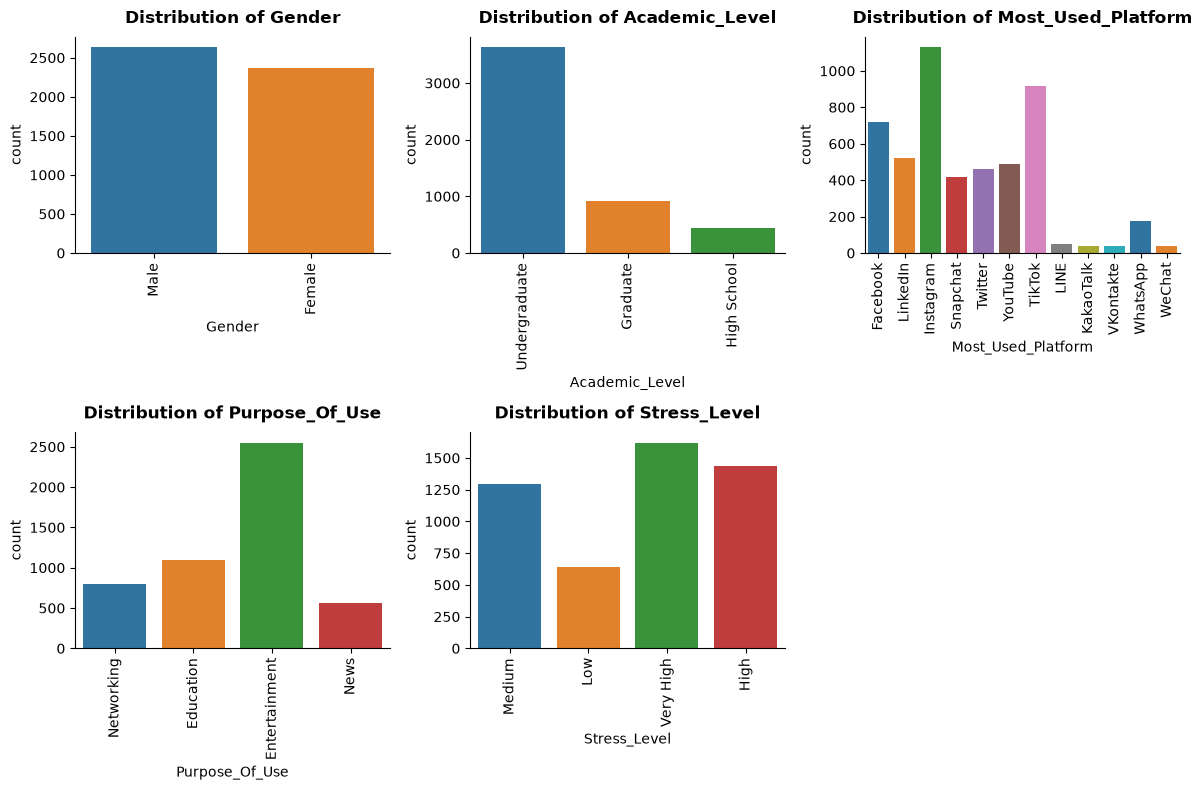

In [ ]:
# Check distribution of categorical columns, excluding Country due to its large number of categories
cat_col = [col for col in df.columns if df[col].dtype == 'str' and col!='Country']

plt.figure(figsize=(12, 8))
for i,col in enumerate(cat_col, 1):
  plt.subplot(2,3,i)
  sns.countplot(data=df, x=col, palette='tab10')
  plt.title(f'Distribution of {col}', fontweight='bold', pad=10)
  plt.xlabel(col)
  plt.xticks(rotation=90)
  sns.despine()
plt.tight_layout()

# Save figure
plt.savefig(
    '../plots/Categorical_Column_Distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

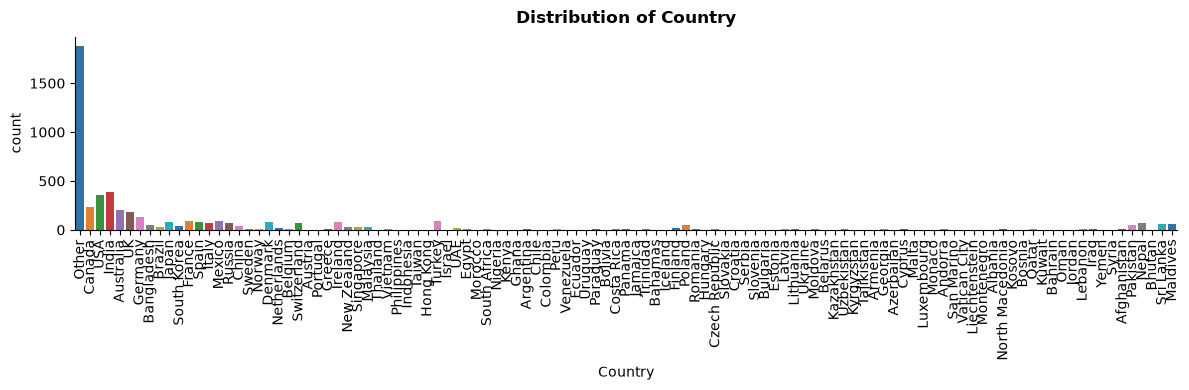

In [34]:
# Check distribution of Country
plt.figure(figsize=(12, 4))
sns.countplot(data=df, x='Country', palette='tab10')
plt.title(f'Distribution of Country', fontweight='bold', pad=10)
plt.xticks(rotation=90)
sns.despine()
plt.tight_layout()

# Save figure
plt.savefig(
    '../plots/Country_Distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

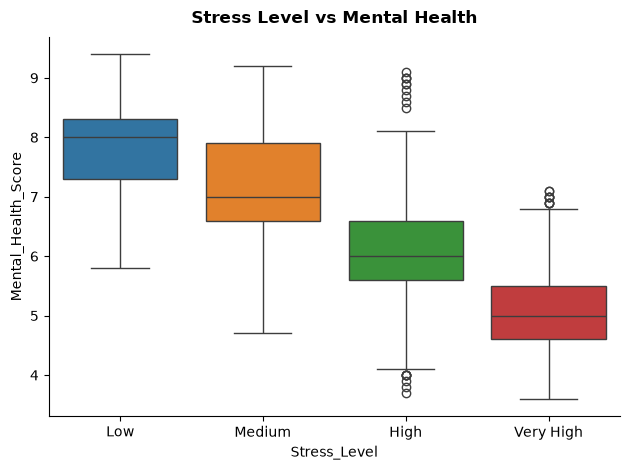

In [38]:
# Check Stress Level vs Mental Health 
order_of_stress_level = ['Low','Medium','High','Very High']
sns.boxplot(data=df, x='Stress_Level',y='Mental_Health_Score',palette='tab10',order=order_of_stress_level)
plt.title(f'Stress Level vs Mental Health', fontweight='bold', pad=10)
sns.despine()
plt.tight_layout()

# Save figure
plt.savefig(
    '../plots/Stress_Level_vs_Mental_Health.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

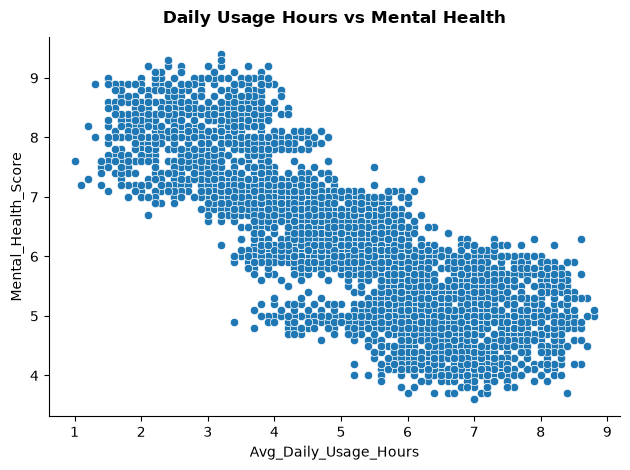

In [42]:
# Check Daily Usage Hours vs Mental Health 
sns.scatterplot(data=df, x='Avg_Daily_Usage_Hours',y='Mental_Health_Score',palette='tab10')
plt.title(f'Daily Usage Hours vs Mental Health', fontweight='bold', pad=10)
sns.despine()
plt.tight_layout()

# Save figure
plt.savefig(
    '../plots/Daily_Usage_Hours_vs_Mental_Health.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

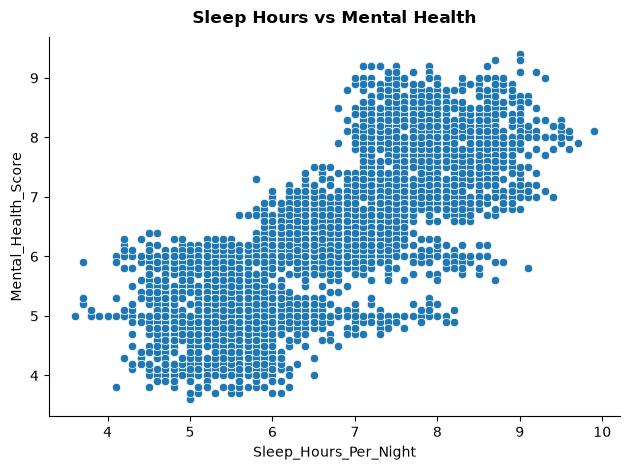

In [43]:
# Check Sleep Hours vs Mental Health 
sns.scatterplot(data=df, x='Sleep_Hours_Per_Night',y='Mental_Health_Score',palette='tab10')
plt.title(f'Sleep Hours vs Mental Health', fontweight='bold', pad=10)
sns.despine()
plt.tight_layout()

# Save figure
plt.savefig(
    '../plots/Sleep_Hours_vs_Mental_Health.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

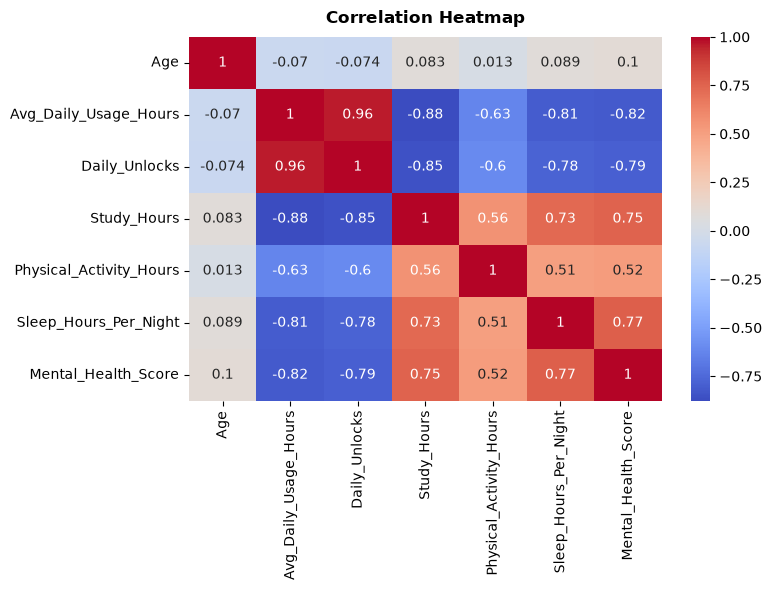

In [51]:
# Check correlation between numerical columns 
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap', fontweight='bold', pad=10)
plt.tight_layout()

# Save figure
plt.savefig(
    '../plots/Correlation_Heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [60]:
# Check outliers

# define numerical features dataframe
numerical_features = df[numerical_columns]

# define q1, q3, iqr 
q1 = numerical_features.quantile(0.25)
q3 = numerical_features.quantile(0.75)
iqr = q3 - q1 

# define lower and upper bound 
lower_bound = q1 - 1.5*iqr
upper_bound = q3 + 1.5*iqr

outliers = (numerical_features < lower_bound) | (numerical_features > upper_bound)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
dtype: int64


#### Observations:

- The `Mental_Health_Score` is mostly between **5** and **8**.

- `Study_Hours` is slightly right-skewed, with most students having lower study hours.

- Most students are Undergraduates, and Entertainment is the most common purpose of social media use.

- Higher `Stress_Level` is associated with lower `Mental_Health_Score`.

- The `Country` column is highly imbalanced, with `Other` having the highest number of records and, India and USA have relatively higher numbers of records compared to most other individual countries.

- Higher `Avg_Daily_Usage_Hours` is associated with lower `Mental_Health_Score`, while higher `Sleep_Hours_Per_Night` is associated with higher `Mental_Health_Score`.

- `Avg_Daily_Usage_Hours` and `Daily_Unlocks` are highly correlated (**0.96**), and a few potential outliers were found in `Study_Hours` and `Physical_Activity_Hours`.

## 4. Data Cleaning

In [3]:
# Drop duplicate values
df = df.drop_duplicates()

# Check again 
df.duplicated().sum()

np.int64(0)

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,4998.0,20.822129,1.736774,18.0,19.0,21.0,22.0,24.0
Avg_Daily_Usage_Hours,4998.0,5.078491,1.654097,1.0,3.8,5.0,6.3,8.8
Daily_Unlocks,4998.0,171.455582,42.859829,62.0,140.0,171.0,204.0,273.0
Study_Hours,4998.0,3.008403,1.636831,0.3,1.5,2.8,4.2,8.3
Physical_Activity_Hours,4998.0,1.750760,0.668406,-0.4,1.3,1.7,2.2,4.1
Sleep_Hours_Per_Night,4998.0,6.634654,1.221561,3.6,5.6,6.6,7.5,9.9
Mental_Health_Score,4998.0,6.231152,1.278476,3.6,5.1,6.1,7.1,9.4


In [5]:
# Convert unrealitstic value -0.4 in  to realistic value in Physical_Activity_Hours
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)

# check 
df['Physical_Activity_Hours'].min()

np.float64(0.0)

In [6]:
# Recheck shape of the cleaned dataset
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 4998
Number of Columns: 13


Now after data cleaning, we have **4998 rows** in the cleaned dataset

In [9]:
# Make copy of the dataset 
df_copy = df.copy()
df_copy.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


## 5. Feature Engineering

- Country has 111 unique values in this dataset, one-hot encoding that directly would add 110+ mostly-empty columns, which hurts the model far more than it helps (this is called high cardinality).
- Dropping Country entirely throws away real signal
- The fix: keep the top 10 most frequent countries as their own category, and bucket everything else into "Other".

In [10]:
# Check Country unique values 
len(df_copy['Country'].unique())

111

In [11]:
# Define top_countries
top_countries = df_copy['Country'].value_counts().index[:10].to_list()
print(top_countries)

['Other', 'India', 'USA', 'Canada', 'Australia', 'UK', 'Germany', 'Mexico', 'Turkey', 'France']


In [12]:
# Group the countries in other only 
def group_countries(country):
    if country in top_countries:
        return country
    else:
        return 'Other'

df_copy['Grouped_country'] = df_copy['Country'].apply(group_countries)
df_copy['Grouped_country'].value_counts()

Grouped_country
Other        3231
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

In [13]:
# Drop Country column
df_copy.drop(columns='Country',inplace=True)

In [14]:
# Check dataset
df_copy.head()

,Age,Gender,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score,Grouped_country
0,21,Male,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8,Other
1,23,Female,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6,Other
2,22,Male,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0,Canada
3,18,Male,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3,Other
4,24,Female,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4,Other


In [15]:
# Save this cleaned dataset 
df_copy.to_csv('../dataset/Cleaned_Dataset.csv',index=False)

In [18]:
# Separat dependent and independent features 
X = df_copy.drop(columns=target_column)
y = df_copy[target_column]

In [19]:
# Check X 
X.head()

,Age,Gender,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Grouped_country
0,21,Male,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,Other
1,23,Female,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,Other
2,22,Male,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,Canada
3,18,Male,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,Other
4,24,Female,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,Other


In [ ]:
# Check y
y.head()

0    6.8
1    7.6
2    7.0
3    5.3
4    4.4
Name: Mental_Health_Score, dtype: float64

## 6. Train-Test Split

In [20]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
         X, y, test_size=0.30, random_state=42)

In [21]:
# Check train shape and test shape 
print(f"Train shape : {X_train.shape}")
print(f"Test shape : {X_test.shape}")

Train shape : (3498, 12)
Test shape : (1500, 12)


## 7. Data Preprocessing

In [22]:
# Define columns for data preprocessing 
skewed_column = ['Study_Hours']

numerical_columns = ['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night']

nominal_columns = ['Gender', 'Academic_Level', 'Most_Used_Platform', 'Purpose_Of_Use', 'Grouped_country']

ordinal_column = ['Stress_Level']  

In [23]:
# Define preprocessing Pipelines

# skewed pipeline 
skewed_pipeline = Pipeline([
    ('log_transform',FunctionTransformer(np.log1p)),
    ('scaler',StandardScaler())
])

# numerical pipeline 
numerical_pipeline = Pipeline([
    ('scaler',StandardScaler())
])

# nominal pipeline 
nominal_pipeline = Pipeline([
    ('ohe',OneHotEncoder(handle_unknown='ignore'))
])

# ordinal pipeline 
stress_order = ['Low', 'Medium', 'High', 'Very High']

ordinal_pipeline = Pipeline([
    ('ordinal',OrdinalEncoder(categories=[stress_order]))
])



# Define ColumnTransformer 
preprocessor = ColumnTransformer(transformers=[
    ('skew', skewed_pipeline, skewed_column),
    ('num', numerical_pipeline, numerical_columns),
    ('nom', nominal_pipeline, nominal_columns),
    ('ord', ordinal_pipeline, ordinal_column)
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('skew', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_

## 8. Model Training & Evaluation

In [28]:
# Baseline - LinearRegression 
lr_pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('lr_model',LinearRegression())
])

# Define a function to evaluate model
def evaluate_model(actual, predicted):
    r2 = r2_score(actual, predicted)
    mae = mean_absolute_error(actual, predicted)
    rmse = root_mean_squared_error(actual, predicted)

    return r2, mae, rmse

lr_pipeline.fit(X_train,y_train)

lr_train_pred = lr_pipeline.predict(X_train)  
lr_test_pred = lr_pipeline.predict(X_test) 

# model evaluation for train and test data
lr_train_r2, lr_train_mae, lr_train_rmse = evaluate_model(y_train, lr_train_pred)
lr_test_r2, lr_test_mae, lr_test_rmse = evaluate_model(y_test, lr_test_pred)

# printing models and performance metrices 
print("========== 'LinearRegression' ==========")

print('r2: ', lr_train_r2)
print('mae: ', lr_train_mae)
print('rmse: ', lr_train_rmse)

print("-"*40)

print('r2: ', lr_test_r2)
print('mae: ', lr_test_mae)
print('rmse: ', lr_test_rmse)

========== 'LinearRegression' ==========
r2:  0.7236771199387539
mae:  0.5189846926901907
rmse:  0.660896991866574
----------------------------------------
r2:  0.7397944617433021
mae:  0.5361775634720181
rmse:  0.6760318429888341


In [31]:
# Define models 
models = {
    'LinearRegression': LinearRegression(),
    'DecisionTreeRegressor': DecisionTreeRegressor(),
    'RandomForestRegressor': RandomForestRegressor(),
    'XGBRegressor': XGBRegressor()
}

# Define a function to evaluate model
def evaluate_model(actual, predicted):
    r2 = r2_score(actual, predicted)
    mae = mean_absolute_error(actual, predicted)
    rmse = root_mean_squared_error(actual, predicted)

    return r2, mae, rmse


# Store results
results = []

# Train and evaluate model 
for name, model in models.items(): 

    # create pipeline for models 
    model_pipeline = Pipeline([
        ('preprocessor',preprocessor),
        ('model',model)
    ])

    # fit model 
    model_pipeline.fit(X_train,y_train)

    # predictions for train and test data 
    y_train_pred = model_pipeline.predict(X_train)
    y_test_pred = model_pipeline.predict(X_test)

    # model evaluation for train and test data
    train_r2, train_mae, train_rmse = evaluate_model(y_train, y_train_pred)
    test_r2, test_mae, test_rmse = evaluate_model(y_test, y_test_pred)

    results.append({
        "Model": name,
        "R2 Score": test_r2,
        "MAE" : test_mae,
        "RMSE": test_rmse
    })

    # printing models and performance metrices 
    print(f"========== {name} ==========")

    print("Model performance for Train data -")
    print(f"R2 Score : {train_r2:.4f}")
    print(f"Mean Absolute Error : {train_mae:.4f}")
    print(f"Root Mean Squared Error : {train_rmse:.4f}")

    print("-"*40)

    print("Model performance for Test data -")
    print(f"R2 Score : {test_r2:.4f}")
    print(f"Mean Absolute Error : {test_mae:.4f}")
    print(f"Root Mean Squared Error : {test_rmse:.4f}")
    print("="*40)
    print("\n")

========== LinearRegression ==========
Model performance for Train data -
R2 Score : 0.7237
Mean Absolute Error : 0.5190
Root Mean Squared Error : 0.6609
----------------------------------------
Model performance for Test data -
R2 Score : 0.7398
Mean Absolute Error : 0.5362
Root Mean Squared Error : 0.6760


========== DecisionTreeRegressor ==========
Model performance for Train data -
R2 Score : 1.0000
Mean Absolute Error : 0.0001
Root Mean Squared Error : 0.0036
----------------------------------------
Model performance for Test data -
R2 Score : 0.7699
Mean Absolute Error : 0.4161
Root Mean Squared Error : 0.6358


========== RandomForestRegressor ==========
Model performance for Train data -
R2 Score : 0.9808
Mean Absolute Error : 0.1259
Root Mean Squared Error : 0.1744
----------------------------------------
Model performance for Test data -
R2 Score : 0.8782
Mean Absolute Error : 0.3478
Root Mean Squared Error : 0.4625


========== XGBRegressor ==========
Model performance for 

In [34]:
# Compare model performance
result_df = pd.DataFrame(results)
result_df = result_df.sort_values(by=['R2 Score','MAE','RMSE'], ascending=False)
result_df

,Model,R2 Score,MAE,RMSE
2,RandomForestRegressor,0.878192,0.347834,0.462537
3,XGBRegressor,0.877166,0.351939,0.464482
1,DecisionTreeRegressor,0.769856,0.416067,0.635783
0,LinearRegression,0.739794,0.536178,0.676032


In [39]:
# Select best model 
best_model = result_df.iloc[0]
best_model

Model       RandomForestRegressor
R2 Score                 0.878192
MAE                      0.347834
RMSE                     0.462537
Name: 2, dtype: object

## 9. Hyperparameter Tuning

In [42]:
# Create a pipeline with preprocessing for best selected model - RandomForest
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# Define parameters for hyperparameter tuning 
params = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [5, 10, 15, 20, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4, 8]
}   

In [51]:
# Hyperparameter tuning using RandomSearchCV 
rs = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=params,
    n_iter=50,
    scoring='r2',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rs.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [5, 10, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to 

In [52]:
# Check best score and params 
print("==== Best Score and Params ====")
print("Best Score:",rs.best_score_)
print("Best Params:",rs.best_params_)

==== Best Score and Params ====
Best Score: 0.852138983854306
Best Params: {'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': None}


In [ ]:
# Define final best random forest model after hyperparameter tuning 
best_rf_model = rs.best_estimator_

# Get final predictions 
final_y_pred = best_rf_model.predict(X_test)

# Final model evaluation
final_r2, final_mae, final_rmse = evaluate_model(y_test, final_y_pred)

print("==== RandomForest — Test Performance ====")
print(f"R2 Score : {final_r2:.4f}")
print(f"MAE      : {final_mae:.4f}")
print(f"RMSE     : {final_rmse:.4f}")

==== RandomForest — Test Performance ====
R2 Score : 0.8774
MAE      : 0.3460
RMSE     : 0.4640


In [54]:
y_train_pred_tuned = best_rf_model.predict(X_train)
tuned_train_r2, tuned_train_mae, tuned_train_rmse = evaluate_model(y_train, y_train_pred_tuned)
print(f"Tuned Train R2: {tuned_train_r2:.4f}")

Tuned Train R2: 0.9808


In [ ]:
# Pipeline with preprocessing + XGBoost
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(random_state=42))
])

# Params — note 'model__' prefix same as before
xgb_params = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [3, 4, 5, 6, 8],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'model__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'model__min_child_weight': [1, 3, 5, 10],
    'model__reg_alpha': [0, 0.01, 0.1, 1],
    'model__reg_lambda': [1, 2, 5, 10]
}

rs_xgb = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=20,
    scoring='r2',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rs_xgb.fit(X_train, y_train)

print("==== Best Score and Params (XGBoost) ====")
print("Best Score:", rs_xgb.best_score_)
print("Best Params:", rs_xgb.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
==== Best Score and Params (XGBoost) ====
Best Score: 0.8657070590154767
Best Params: {'model__subsample': 0.8, 'model__reg_lambda': 2, 'model__reg_alpha': 1, 'model__n_estimators': 500, 'model__min_child_weight': 5, 'model__max_depth': 8, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}


In [ ]:
best_xgb_model = rs_xgb.best_estimator_

final_y_pred_xgb = best_xgb_model.predict(X_test)
final_r2_xgb, final_mae_xgb, final_rmse_xgb = evaluate_model(y_test, final_y_pred_xgb)

print("==== Tuned XGBoost — Test Performance ====")
print(f"R2 Score : {final_r2_xgb:.4f}")
print(f"MAE      : {final_mae_xgb:.4f}")
print(f"RMSE     : {final_rmse_xgb:.4f}")



==== Tuned XGBoost — Test Performance ====
R2 Score : 0.8878
MAE      : 0.3311
RMSE     : 0.4440
Tuned Train R2: 0.9857


In [60]:
# check train too, for overfitting gap
y_train_pred_xgb = best_xgb_model.predict(X_train)
train_r2_xgb, train_mae_xgb, train_rmse_xgb = evaluate_model(y_train, y_train_pred_xgb)
print(f"Tuned Train R2: {train_r2_xgb:.4f}")

Tuned Train R2: 0.9857
